# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__[Startup Investments]__

## Selected Problem Statement: 
__[Approach: Optimal Funding Trajectories for Follow-On Investment
Problem Statement: A venture capital firm struggles to reliably select seed-stage startups that will eventually secure follow-on funding, resulting in a portfolio of stalled companies. The Investment Analytics team needs to analyze historical funding data across industry categories, funding round counts, time between rounds, and geographic regions to identify the patterns most strongly associated with startups that successfully raise additional capital. Uncovering these historical trajectories will allow the firm to accurately refine its $10M seed-stage investment criteria and target startups with the highest odds of advancing.]__

## 1. Introduction & Objectives
*(Guidelines: Introduce your topic and give a brief high-level overview of the industry or topic you are exploring so a non-technical audience understands the context.)*

### 1.1 Context & Background
Venture capital companies invest in startup firms even before they become profitable. In the seed round, a small amount invested to the startups to prove their ideas. This is just the begining, the to grow, startups go to the market and rise follow-on rounds, each round is multible investors, checking the firm and deciding the worth, that is must be more than before. If the startup firm did the seed stage only and no more rounds, that means its stopped or stuck, and mostly no return or profit.

The portfolio of the venture capital firm is now full of stalled companies, and a $10M to invest in startups who in seed stage, but with not just guissing. The question is: What kind of seed-stage startups have istorically gone on to raise again?

Using Crunchbase data, records of companies worldwide, company's industry, location, date etc... we will answer that question.

### 1.2 Core Analytical Objectives
*(List the key targeted questions that will guide your analysis to solve the chosen problem statement. Use bullet points.)*

The client invests in seed-stage startups, so our analysis focus on companies raised seed round, and measure of sccess is if the company went to at least additional round.

* 1_ What % of all seed-stage startups raised again? (Baseline - Benchmark)
* 2_ What markets or industries produce seed-stage firms that excced the baseline? (Industry category)
* 3_ Is the region/country effects the odd of raising again? (Geographic region)
* 4_ How many rounds startup firms usually do? and does a 2nd round predict the eventual outcome (closed, operating...) of the company? (Round counts)
* 5_ How long between the round for the startups that do advance? How long it takes before deciding an investment in stalled. (Time between rounds)
* 6_ As recommendation, what screening criteria the firm shoud do to the $10M? and how well these criteria did an improment.

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To make it full display for all the columns
pd.set_option('display.max_columns', None)

# To make all upcoming graphs consist
sns.set_style('whitegrid')

In [2]:
# Load data using strictly relative file paths
startups = pd.read_csv('../data/startup_investments.csv', encoding = 'latin-1')
# The latin-1 fix the error by using default read_csv

In [3]:
# To confirm the loading
startups.head(2)

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2.0,NaN,NaN,NaN,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# To check the shpae, number of firms(rows) and columns(attribute) of each firm.
startups.shape

(54294, 39)

---
## 3. Data Handling


* Before cleaning, we will point structural problems, null values, or wrong data types.

In [5]:
# Initial assessment: Check shapes, null values, and summary data types

In [6]:
startups.info()
# The dates columns are stored as str, also the funding_total_usd is as str.
# Many columns non-null count is exactly 49438 out of 54294

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  str    
 1   name                  49437 non-null  str    
 2   homepage_url          45989 non-null  str    
 3   category_list         45477 non-null  str    
 4    market               45470 non-null  str    
 5    funding_total_usd    49438 non-null  str    
 6   status                48124 non-null  str    
 7   country_code          44165 non-null  str    
 8   state_code            30161 non-null  str    
 9   region                44165 non-null  str    
 10  city                  43322 non-null  str    
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38482 no

In [7]:
startups.columns.to_list() #The  ' market ',' funding_total_usd ' columns both have literal spaces

['permalink',
 'name',
 'homepage_url',
 'category_list',
 ' market ',
 ' funding_total_usd ',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

In [8]:
# Percentage of missing values in each column
(startups.isnull().mean()*100).sort_values(ascending = False)

state_code              44.448742
founded_quarter         29.122923
founded_month           29.122923
founded_year            29.122923
founded_at              28.990312
city                    20.208494
region                  18.655837
country_code            18.655837
 market                 16.252256
category_list           16.239363
homepage_url            15.296350
status                  11.364055
name                     8.945740
 funding_total_usd       8.943898
permalink                8.943898
funding_rounds           8.943898
first_funding_at         8.943898
last_funding_at          8.943898
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt            8.943898
secondary_mark

In [9]:
# Many columns share the same % of missing values (8.94%)
# that means the same whole rows are missing from all columns

# To check number of rows where all columns are missing:
startups.isnull().all(axis = 1).sum()

np.int64(4856)

In [10]:
# To check some of fully empty rows
startups[startups.isnull().all(axis = 1)].head(2)

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# To check number of duplicated row
startups.duplicated().sum()
# The number is same as the null rows (1st original and 4855 duplicates)
# So, its the same problem, removing the nulls will eliminate the duplicates

np.int64(4855)

In [12]:
# To check what the values in the (funding_total_usd) looks loke, as they are stored as str
startups[' funding_total_usd '].head(3)
# we can see that numbers are seperated by ',', and the '-' means (no disclosed fundings),
# and also it seems ther are some spaces in it too.

0     17,50,000 
1     40,00,000 
2        40,000 
Name:  funding_total_usd , dtype: str

In [13]:
# Now lets check the values in (Market), are there spaces as the column name is?
startups[' market '].head(3).to_list()
# And the answer is YES there are spaces for some reason.

[' News ', ' Games ', ' Publishing ']

In [14]:
# summary statistics for numeric values
startups.describe()
# We can notice that funding rounds  median is 1 and max is 18 (positive skewed)
# most companies do one round only.
# Also, the founded_year starts from 1902 till 2014. 
# Finally, the funding_total_usd is missing because the data stored as str.

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,38482.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,2007.359129,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,1.628453e+05,2.074286e+06,6.088736e+05,4.434360e+05,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,7.579203,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,5.612088e+06,3.167231e+07,2.678348e+07,3.428169e+07,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,1902.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,2006.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,7.505000e+08,3.500000e+09,4.700000e+09,5.800000e+09,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [15]:
# Data cleaning operations (handling data types, text styling, missing values, etc.)

## 3.2 Cleanin Operations
* Solving each problrm in order that eachg step makes the next possible.
* Fix columns names, drop nulls rows, then correct data types.

In [16]:
# Fix 1) removing all spaces from column names
startups.columns = startups.columns.str.strip()

# To check:
startups.columns.to_list()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

In [17]:
# Fix 2) Tp drop all the nulls fully empty rows 4,856, using (how = 'all') to drop the row only if all columns are nulls
startups = startups.dropna(how = 'all')

# To check:
startups.isnull().all(axis=1).sum()

np.int64(0)

In [18]:
# To confirm that the duplicates are gone as they are the same as the fully nulls rows
startups.duplicated().sum()

np.int64(0)

In [19]:
# But, what about duplicates of compnies? lets check if the 'uniqe' permalink identifier is duplicated or not
startups[startups['permalink'].duplicated(keep = False)]

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
33939,/organization/prysm,Prysm,http://www.prysm.com/,NaN,NaN,"29,30,80,123",operating,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2014-11-25,2014-11-25,0.0,2750000.0,0.0,0.0,0.0,0.0,0.0,0.0,290330123.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33940,/organization/prysm,Prysm,http://www.prysm.com,|Displays|Hardware + Software|,Displays,"29,30,80,123",operating,USA,CA,SF Bay Area,San Jose,3.0,2005-01-01,2005-01,2005-Q1,2005.0,2010-01-05,2011-10-27,0.0,2750000.0,0.0,0.0,0.0,0.0,0.0,0.0,290330123.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44033,/organization/treasure-valley-urology-services,Treasure Valley Urology Services,NaN,|Biotechnology|,Biotechnology,"3,32,194",operating,USA,TX,Austin,Austin,4.0,2004-01-01,2004-01,2004-Q1,2004.0,2009-09-09,2014-05-05,45321.0,286873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44034,/organization/treasure-valley-urology-services,Treasure Valley Urology Services,NaN,NaN,NaN,"3,32,194",operating,USA,TX,Austin,Austin,1.0,2004-01-01,2004-01,2004-Q1,2004.0,2014-07-18,2014-07-18,45321.0,286873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# We can see 2 companies are duplicated.
# each company have one more complete row, and one with nulls in it.
# so, we will keep the one more complete from each company, by sorting funding_rounds to be the first is the nore funding_rounds, then drop the later duplicate

startups = startups.sort_values('funding_rounds', ascending = False)
startups = startups.drop_duplicates(subset = 'permalink', keep = 'first')

# reset the index after drops, then confirm no duplicates in permalink
startups = startups.reset_index(drop=True)
startups['permalink'].duplicated().sum()

np.int64(0)

In [21]:
# Fix 3) Values in 'market' are space padded, so we will strip them
startups['market'] = startups['market'].str.strip()

# To check:
startups['market'].head(5).to_list()

['Enterprise Software', 'Mobile', 'Payments', 'Mobile', 'Software']

In [22]:
# Fix 4) 'funding_total_usd' stored as text, with sopces and commas, and also a '-' for companies with no disclosed funding

# first, remove padding:
funding = startups['funding_total_usd'].str.strip()
# Then, remove the commas
funding = funding.str.replace(',','', regex = False)
# Then, make the (-) as null
funding = funding.replace('-', np.nan)

# Finally, convert to numeric
startups['funding_total_usd'] = pd.to_numeric(funding, errors = 'coerce')

# To check
startups['funding_total_usd'].describe()

count    4.090500e+04
mean     1.590613e+07
std      1.686773e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

In [23]:
# Fix 5) some columns keep dates as text, to convert them to date data type:
startups['founded_at'] = pd.to_datetime(startups['founded_at'], errors = 'coerce')
startups['first_funding_at'] = pd.to_datetime(startups['first_funding_at'], errors = 'coerce')
startups['last_funding_at'] = pd.to_datetime(startups['last_funding_at'], errors = 'coerce')

# To check:
startups.dtypes

permalink                          str
name                               str
homepage_url                       str
category_list                      str
market                             str
funding_total_usd              float64
status                             str
country_code                       str
state_code                         str
region                             str
city                               str
funding_rounds                 float64
founded_at              datetime64[us]
founded_month                      str
founded_quarter                    str
founded_year                   float64
first_funding_at        datetime64[us]
last_funding_at         datetime64[us]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                          float64
grant                    

In [24]:
# Lets look at the early dates for 'first_funding_at', are these real?
early = startups[startups['first_funding_at'].dt.year < 1900]
early['first_funding_at'].dt.year.value_counts().sort_index()

first_funding_at
1      3
7      1
11     1
19     1
20     1
26     1
29     1
201    1
Name: count, dtype: int64

In [25]:
# what about the dates for 'last_funding_at', are these real?
last = startups[startups['last_funding_at'].dt.year < 1900]
last['last_funding_at'].dt.year.value_counts().sort_index()

last_funding_at
1      3
26     1
29     1
201    1
Name: count, dtype: int64

In [26]:
# also, what about the dates for 'founded_at', are these real?
old = startups[startups['founded_at'].dt.year < 1900]
old['founded_at'].dt.year.value_counts().sort_index()

founded_at
1636    1
1785    1
1802    1
1817    1
1826    1
1831    1
1834    1
1838    2
1840    2
1845    1
1847    1
1850    1
1853    1
1854    1
1855    1
1856    2
1857    1
1859    1
1860    2
1861    1
1862    1
1863    3
1864    1
1865    4
1869    2
1870    1
1871    1
1872    1
1873    3
1879    2
1881    3
1883    1
1884    3
1885    2
1886    1
1887    3
1888    1
1889    1
1890    1
1891    2
1892    1
1895    2
1896    1
1897    2
1898    1
Name: count, dtype: int64

* So, 10 corrupt `first_funding_at` dates (year < 1900, e.g. 7, 201) we will set them to NaT.
* Also, 6 corrupt `last_funding_at` dates (year < 1900, e.g. 26, 201) we will set them to NaT.
* But, the 'founded_at' dates all are real and kept.

In [27]:
# To replace these 10 corrupt dates with Nat (so they can't miscalculate the dates later)
bad_dates = startups['first_funding_at'].dt.year < 1900
startups.loc[bad_dates, 'first_funding_at'] = pd.NaT

# lets check if the earliest first_funding date now is real one
startups['first_funding_at'].min()

Timestamp('1921-09-01 00:00:00')

In [28]:
# lets do the same for 'last_funding_at'
bad_last = startups['last_funding_at'].dt.year < 1900
startups.loc[bad_last, 'last_funding_at'] = pd.NaT

# And to check if the earliest last_funding date now is real one
startups['last_funding_at'].min()

Timestamp('1921-09-01 00:00:00')

In [29]:
# Final check before saving the cleaned data
startups.info()

<class 'pandas.DataFrame'>
RangeIndex: 49436 entries, 0 to 49435
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   permalink             49436 non-null  str           
 1   name                  49435 non-null  str           
 2   homepage_url          45988 non-null  str           
 3   category_list         45477 non-null  str           
 4   market                45470 non-null  str           
 5   funding_total_usd     40905 non-null  float64       
 6   status                48122 non-null  str           
 7   country_code          44164 non-null  str           
 8   state_code            30160 non-null  str           
 9   region                44164 non-null  str           
 10  city                  43321 non-null  str           
 11  funding_rounds        49436 non-null  float64       
 12  founded_at            38553 non-null  datetime64[us]
 13  founded_month         38481

In [30]:
# Before EDA, lets save the cleaned dataset:
startups.to_csv('../data/startup_investments_clean.csv', index = False)

---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1. Defining population and target.

Two decisions shape the entire analysis:

**Population — who we study.** Our stakeholder invests at *seed stage*. Studying all
49,436 companies would answer the wrong question, because not all of them took a seed
round. We therefore restrict the analysis to companies with a recorded seed investment
(`seed > 0`). This is the only population the firm's $10M decision applies to.

**Target — what "success" means.** The firm's problem is *stalled* companies: startups
that raise seed money and never raise again. So we define success as raising **more than
one funding round**. A company with `funding_rounds > 1` advanced; a company stuck at
exactly one round stalled. This becomes our target column, `follow_on`.

In [31]:
# To restrict to companies raised seed round
seed = startups[startups['seed']>0].copy()

# Lets check how many companies are seed-stage
seed.shape


(13839, 39)

In [32]:
# To build the target column 'follow_on' if the company raised more than 1 funding round
# storing (True = company advances / False = company stalled)
seed['follow_on'] = seed['funding_rounds'] > 1

# To check the new column
seed[['name','funding_rounds','follow_on']]

,name,funding_rounds,follow_on
1,Mobivery,16.0,True
2,Tyro Payments,15.0,True
24,RealSpeaker Inc,12.0,True
31,WiSpry,11.0,True
36,Sitrion,11.0,True
...,...,...,...
49410,(In)Touch Network,1.0,False
49414,zwoor.com,1.0,False
49420,GMG33,1.0,False
49432,1000 Markets,1.0,False


In [33]:
# What is the mean of seed-stage companies that raised follow_on round?
seed['follow_on'].mean() * 100

np.float64(41.15904328347424)

In [34]:
# How many advanced and how many stalled companies? (True = company advances / False = company stalled)
seed['follow_on'].value_counts()

follow_on
False    8143
True     5696
Name: count, dtype: int64

Only 5,696 out of 13,839 seed-stage companies raised a follow_on round (41.2%)
The remainig stalled at seed (raised funding once only)

So, almost 60% of seed investments stall. Every examination below is juged against this baseline (41.2%), a subgroup will be useful to the firm only if its follow_on rate beats the baseline.

### 4.2. follow_on rate by Industry Category

Which markets produce seed-stage startups that advance at a rate above the 41.2% baseline, and
which fall below it? The firm can then tilt its $10M toward the winning categories.

In [35]:
# Follow-on rate for every market, highest first.
seed.groupby('market')['follow_on'].mean().sort_values(ascending=False).head()

market
Infrastructure Builders    1.0
Innovation Engineering     1.0
Intellectual Property      1.0
Interior Design            1.0
Internet Infrastructure    1.0
Name: follow_on, dtype: float64

In [36]:
# THe output is misleading
# How many seed companies are actually in those "100%" markets?
seed['market'].value_counts().loc[['Infrastructure Builders', 'Innovation Engineering', 'Intellectual Property']]

market
Infrastructure Builders    1
Innovation Engineering     2
Intellectual Property      1
Name: count, dtype: int64

In [37]:
# To trust a market's follow-on rate, we need enough companies behind it.
# Compute BOTH the rate (mean) and the count (size) for each market.
market_stats = seed.groupby('market')['follow_on'].agg(['mean', 'count'])

# Keep only markets with a meaningful sample: at least 100 seed companies.
market_stats = market_stats[market_stats['count'] >= 100]

# Sort by follow-on rate, best first
market_stats = market_stats.sort_values('mean', ascending=False)

market_stats

,mean,count
market,,
Finance,0.595041,242
Health Care,0.544643,224
Biotechnology,0.528481,316
SaaS,0.517857,112
Hardware + Software,0.512195,164
Analytics,0.507463,201
Enterprise Software,0.487544,281
Mobile,0.474763,634
Advertising,0.449477,287


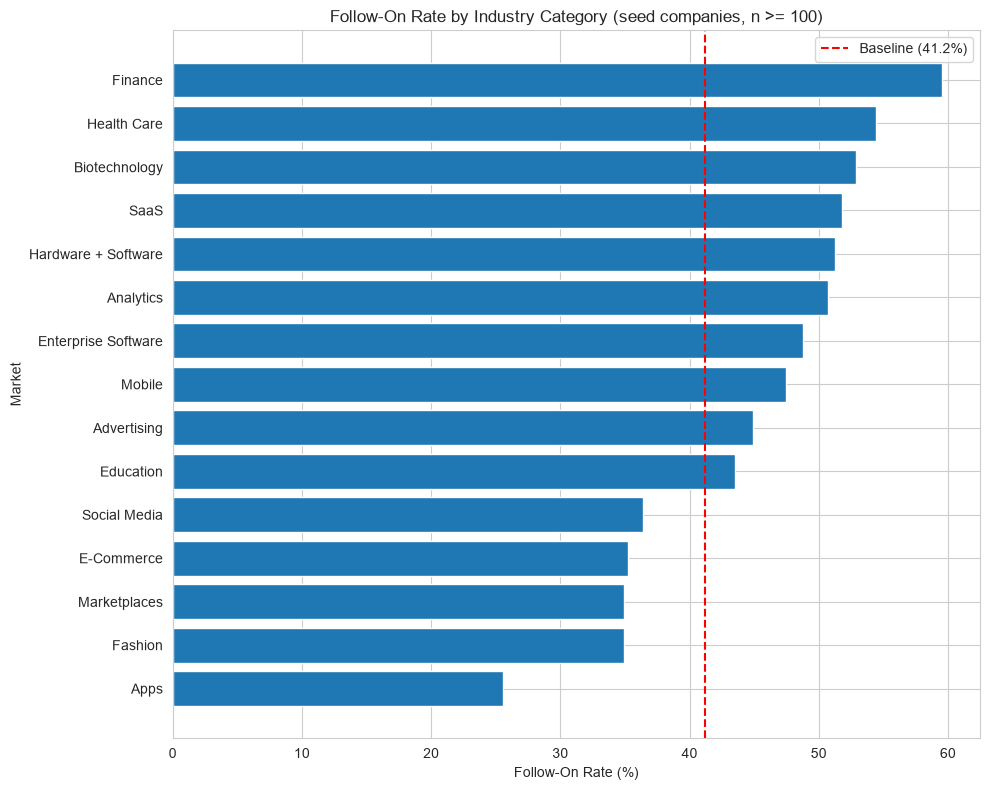

In [55]:
# Take the strongest and weakest markets to show the full spread
top_markets = market_stats.head(10)
bottom_markets = market_stats.tail(5)
plot_markets = pd.concat([top_markets, bottom_markets])

# Horizontal bar chart of follow-on rate by market
plt.figure(figsize=(10, 8))
bars = plt.barh(plot_markets.index, plot_markets['mean'] * 100)

# Add the 41.2% baseline as a reference line
baseline = seed['follow_on'].mean() * 100
plt.axvline(baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.1f}%)')

plt.xlabel('Follow-On Rate (%)')
plt.ylabel('Market')
plt.title('Follow-On Rate by Industry Category (seed companies, n >= 100)')
plt.legend()
# To make highest rate at the top:
plt.gca().invert_yaxis()   
plt.tight_layout()
plt.show()

**Visualization 1 Interpretation:**

Industry category strongly separates winners from stallers. **Finance (60%), Health Care
(54%), Biotechnology (53%), and SaaS (52%)** seed startups all clear the 41.2% baseline
comfortably — a Finance seed company is far more likely to raise again than the average.
At the other end, **Apps (26%), Fashion (35%), E-Commerce (35%), and Marketplaces (35%)**
sit well below the line.

This directly informs the screening criteria: the $10M should tilt toward
enterprise, financial, and health/biotech categories and away from consumer apps and
fashion.

### 4.3. follow-on rate by Geographic Region

The second factor is **geography**. Does the country where a startup is headquartered
change its odds of raising again? If certain ecosystems reliably produce follow-on
companies, the firm can weight its screening toward them.

In [39]:
# Follow-on rate and company count per country
country_stats = seed.groupby('country_code')['follow_on'].agg(['mean', 'count'])

# Keep only countries with at least 100 seed companies, for the same small-sample
# reason as the market analysis
country_stats = country_stats[country_stats['count'] >= 100]

# Sort by follow-on rate, best first
country_stats = country_stats.sort_values('mean', ascending=False)

country_stats

,mean,count
country_code,,
USA,0.499716,7052
ISR,0.453552,183
JPN,0.450980,102
AUS,0.443609,133
ITA,0.440000,125
ESP,0.417021,235
DEU,0.404167,240
IRL,0.398438,128
ARG,0.392523,107


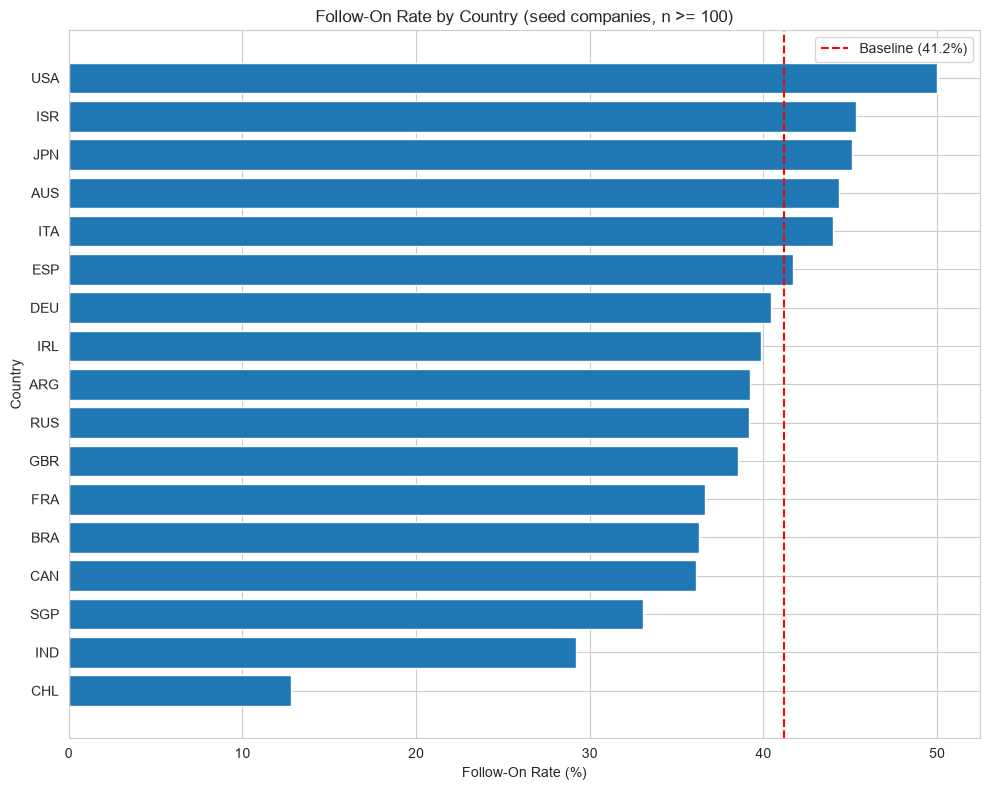

In [40]:
# Plot every qualifying country against the baseline
plt.figure(figsize=(10, 8))
plt.barh(country_stats.index, country_stats['mean'] * 100)

# baseline reference line
baseline = seed['follow_on'].mean() * 100
plt.axvline(baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.1f}%)')

plt.xlabel('Follow-On Rate (%)')
plt.ylabel('Country')
plt.title('Follow-On Rate by Country (seed companies, n >= 100)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Visualization 2 Interpretation:**

The **USA dominates** — not only does it hold **7,052** of the qualifying seed companies
(more than all other countries combined), it also posts a **50% follow-on rate**, nearly
9 points above the global baseline. American seed startups are meaningfully more likely to
raise again, reflecting the depth of the US venture market.

A tier of ecosystems — **Japan (45%), Australia and Italy (44%)** — also clear
the baseline. At the bottom, **CHL stands out as a warning: just 13%** across 273
companies, less than a third of the US rate, and **India (29%)** also lags. Geography is a
real filter: a seed dollar in the US has far better historical odds of advancing
than one in CHL or India.

### 4.4. Funding Round Counts and Company Outcomes

The third factor is **funding round counts**. Two questions: how many rounds do seed
startups typically reach, and does following on actually lead to better
outcomes? If companies that raise again are no more likely to succeed, our whole target
is meaningless. We test that here by linking `follow_on` to each company's final status
(operating, acquired, or closed).

In [41]:
# How many total funding rounds do seed-stage companies reach?
seed['funding_rounds'].value_counts().sort_index()

funding_rounds
1.0     8143
2.0     3158
3.0     1400
4.0      602
5.0      281
6.0      140
7.0       56
8.0       26
9.0       17
10.0       7
11.0       6
12.0       1
15.0       1
16.0       1
Name: count, dtype: int64

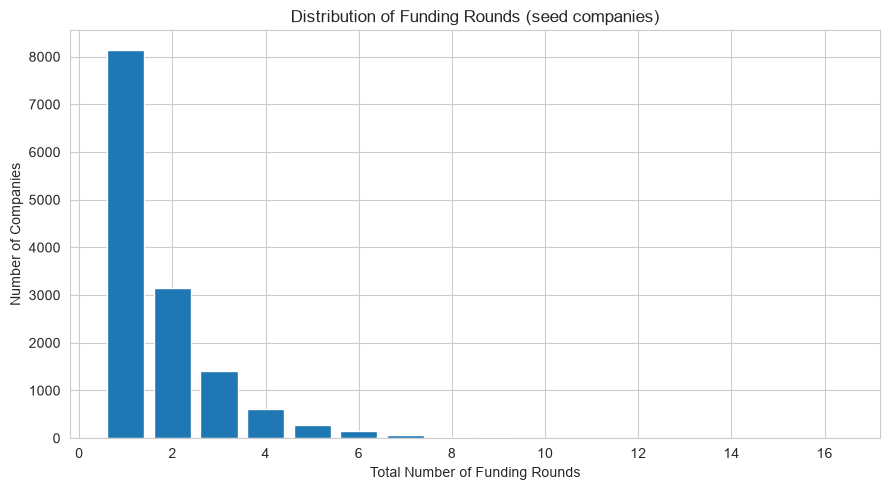

In [42]:
# Distribution of total funding rounds among seed companies
plt.figure(figsize=(9, 5))
round_counts = seed['funding_rounds'].value_counts().sort_index()
plt.bar(round_counts.index, round_counts.values)
plt.xlabel('Total Number of Funding Rounds')
plt.ylabel('Number of Companies')
plt.title('Distribution of Funding Rounds (seed companies)')
plt.tight_layout()
plt.show()

**Visualization 3 Interpretation:**

The distribution is right-skewed. The largest single group — **8,143 companies
(59%)** — stalls at one round. Each additional round roughly halves the survivors: 3,158
reach two, 1,400 reach three, and the numbers thin quickly after that. Advancing is the
exception, not the rule, which is exactly why the firm needs a way to pick the exceptions
in advance.

In [43]:
# Outcome status available for seed companies (some are unknown)
seed['status'].value_counts(dropna=False)

status
operating    12071
closed         771
acquired       591
NaN            406
Name: count, dtype: int64

In [44]:
# Compare final outcomes for companies that followed on vs. those that stalled.
# normalize='index' turns the counts into row percentages, so each row sums to 100%.
outcome = pd.crosstab(seed['follow_on'], seed['status'], normalize='index') * 100
outcome.round(1)

status,acquired,closed,operating
follow_on,,,
False,3.0,7.5,89.5
True,6.4,3.3,90.3


Companies that followed on get acquired at 6.4% vs. 3.0% for stalled ones (Acquisition = the investor gets paid; it's the good exit.)
Companies that stalled get closed at 7.5% vs. 3.3%

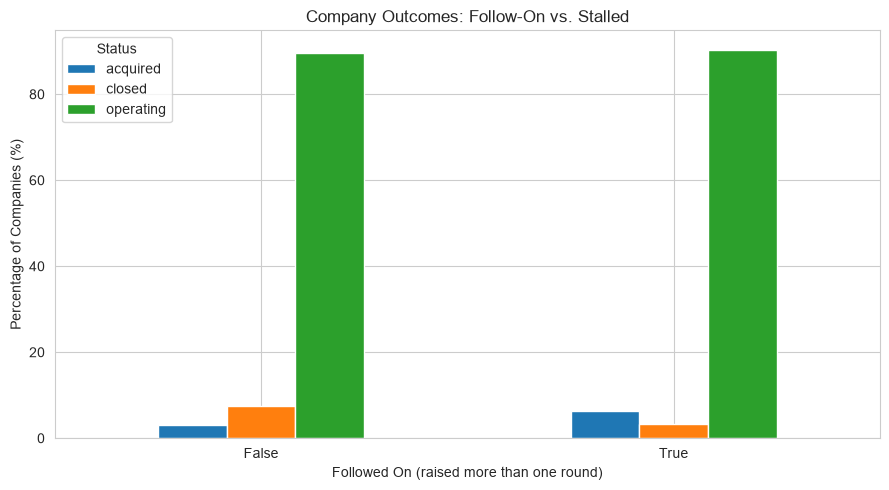

In [45]:
# Visualize the outcome mix for each group as a grouped bar chart
outcome_plot = pd.crosstab(seed['follow_on'], seed['status'], normalize='index') * 100

outcome_plot.plot(kind='bar', figsize=(9, 5))
plt.xlabel('Followed On (raised more than one round)')
plt.ylabel('Percentage of Companies (%)')
plt.title('Company Outcomes: Follow-On vs. Stalled')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Visualization 4 Interpretation:**

Following on is not just "more funding", it predicts a materially better ending.
Companies that raised beyond seed were **acquired at 6.4% vs. 3.0%** for stalled companies and **closed at only 3.3% vs. 7.5%**.  Stalled seed companies are roughly **twice as likely to
die and half as likely to be acquired.**

This validates the entire premise of the analysis: `follow_on` is a meaningful success
signal, not an arbitrary line. Helping the firm pick follow-on companies genuinely means
helping it pick companies that survive and exit well.

### 4.5. Time Between Funding Rounds

The final factor is **timing**. For companies that do advance, how long is the typical gap
between funding rounds? This answers a practical question the firm faces constantly: after
a seed investment, how long should it wait before concluding a company has stalled? A
company that hasn't raised in 8 months may just be early; one silent for 3 years is likely
dead.

In [46]:
# "Time between rounds" only applies to companies that raised more than once.
# Restrict to follow-on companies.
followed = seed[seed['follow_on']].copy()

# We have the first and last funding dates but not each round's date. So we estimate the
# average gap: total time from first to last round, divided by the number of GAPS between
# rounds (which is funding_rounds - 1).
followed['span_days'] = (followed['last_funding_at'] - followed['first_funding_at']).dt.days
followed['avg_gap_days'] = followed['span_days'] / (followed['funding_rounds'] - 1)

followed[['name', 'funding_rounds', 'span_days', 'avg_gap_days']].head()

,name,funding_rounds,span_days,avg_gap_days
1,Mobivery,16.0,2092.0,139.466667
2,Tyro Payments,15.0,3236.0,231.142857
24,RealSpeaker Inc,12.0,719.0,65.363636
31,WiSpry,11.0,3844.0,384.400000
36,Sitrion,11.0,3666.0,366.600000


In [47]:
# Some gaps are invalid: a few dates are missing (NaN), zero-or-negative gap (same-day first/last funding recorded 
# keep only positive, real gaps.
valid_gaps = followed[followed['avg_gap_days'] > 0]

valid_gaps['avg_gap_days'].describe()

count     5602.000000
mean       390.197825
std        371.974827
min          1.000000
25%        184.000000
50%        309.250000
75%        482.458333
max      10052.000000
Name: avg_gap_days, dtype: float64

In [48]:
# The typical gap between rounds (median is robust to the long tail of outliers)
median_gap = valid_gaps['avg_gap_days'].median()
print(f'Median gap between rounds: {median_gap:.0f} days')

# What share of follow-on companies raised again within one year? Within two?
within_1yr = (valid_gaps['avg_gap_days'] <= 365).mean() * 100
within_2yr = (valid_gaps['avg_gap_days'] <= 730).mean() * 100
print(f'Raised again within 1 year: {within_1yr:.0f}%')
print(f'Raised again within 2 years: {within_2yr:.0f}%')

Median gap between rounds: 309 days
Raised again within 1 year: 60%
Raised again within 2 years: 90%


So, if a seed company hasn't raised again after two years, it's in the 10% tail, overwhelmingly likely stalled.

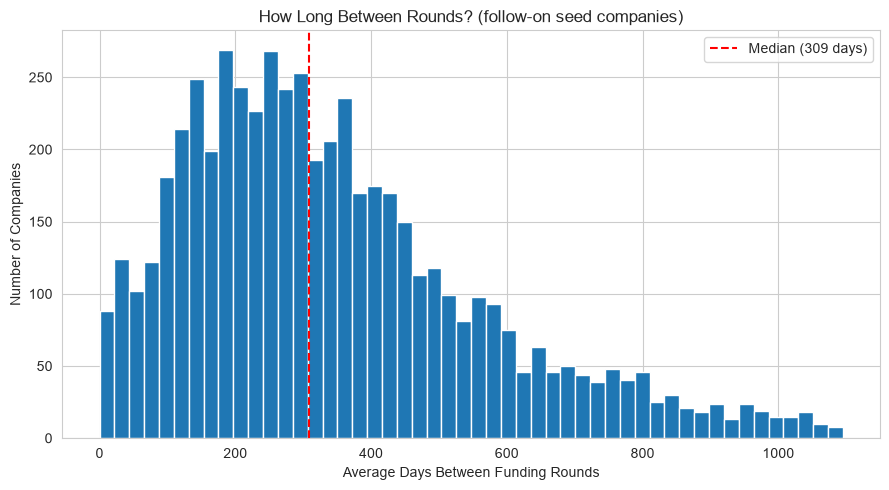

In [49]:
# Distribution of the average gap between rounds for follow-on companies.
# Cap the x-axis at ~3 years so the long outlier tail doesn't flatten the shape.
plt.figure(figsize=(9, 5))
plt.hist(valid_gaps['avg_gap_days'], bins=50, range=(0, 1095))

# Mark the median
plt.axvline(median_gap, color='red', linestyle='--', label=f'Median ({median_gap:.0f} days)')

plt.xlabel('Average Days Between Funding Rounds')
plt.ylabel('Number of Companies')
plt.title('How Long Between Rounds? (follow-on seed companies)')
plt.legend()
plt.tight_layout()
plt.show()

**Visualization 5 Interpretation:**


Among companies that advance, the follow-on round comes quickly: the median gap is about
**309 days**. 60% raise again within a **single year**, and
**90% within two years.**

This gives the firm a concrete monitoring rule. A seed company that has not raised again
after ~12 months is not yet a concern, most winners are only just clearing that mark. But
a company silent past the **two-year** point falls into the 10% tail and is very likely
stalled. **Two years is the point at which the firm should stop expecting follow-on funding
and treat the investment as inactive.**

### Before Part 5

In [50]:
# if the firm screened on the winning markets AND the winning countries together, what follow-on rate would it get?

# These are the categories that beat the baseline in sections 4.2 and 4.3.
winning_markets = ['Finance', 'Health Care', 'Biotechnology', 'SaaS', 'Hardware + Software', 'Analytics', 'Enterprise Software']
winning_countries = ['USA', 'ISR', 'JPN', 'AUS', 'ITA']

# A company passes the screen if it is in BOTH a winning market and a winning country.
screen = seed[seed['market'].isin(winning_markets) & seed['country_code'].isin(winning_countries)]

# Compare the screened group's follow-on rate against the baseline
baseline_rate = seed['follow_on'].mean() * 100
screened_rate = screen['follow_on'].mean() * 100

print(f'Baseline follow-on rate:  {baseline_rate:.1f}%  (all {len(seed):,} seed companies)')
print(f'Screened follow-on rate:  {screened_rate:.1f}%  ({len(screen):,} companies pass)')

Baseline follow-on rate:  41.2%  (all 13,839 seed companies)
Screened follow-on rate:  60.9%  (1,024 companies pass)


In [51]:
# What would this screen have meant for the firm's $10M?
# Using the median seed cheque as a realistic ticket size:
cheque = seed['seed'].median()          
n_investments = int(10000000 / cheque)  # number of seed bets $10M buys

baseline_advancing = (baseline_rate/100) * n_investments
screened_advancing = (screened_rate/100) * n_investments

print(f'A $10M fund at a ${cheque:,.0f} median cheque = {n_investments} seed investments.')
print(f'  Investing at random (baseline): ~{baseline_advancing:.0f} advance to a follow-on round')
print(f'  Investing through the screen:   ~{screened_advancing:.0f} advance')
print(f'  Net gain: ~{screened_advancing - baseline_advancing:.0f} more advancing companies from the same $10M')

A $10M fund at a $300,000 median cheque = 33 seed investments.
  Investing at random (baseline): ~14 advance to a follow-on round
  Investing through the screen:   ~20 advance
  Net gain: ~7 more advancing companies from the same $10M


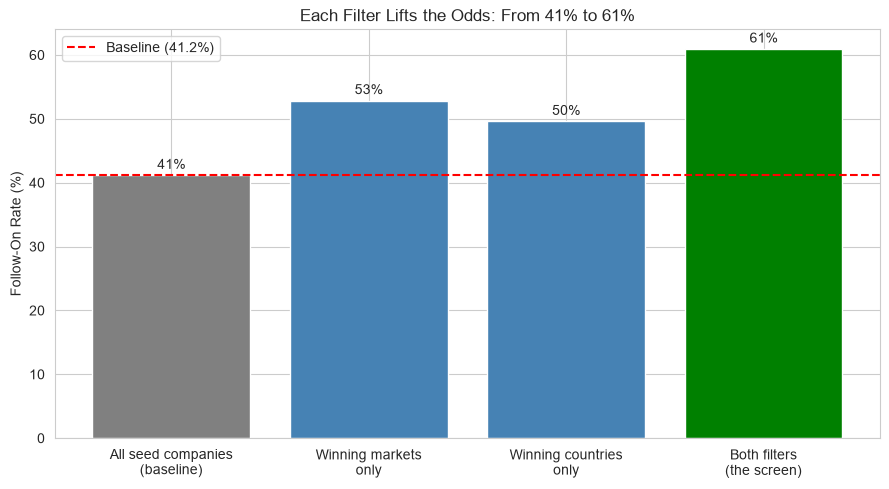

In [ ]:
# Show how each successive filter lifts the follow-on rate above the baseline
scenarios = {
    'All seed companies\n(baseline)': baseline_rate,
    'Winning markets\nonly': seed[seed['market'].isin(winning_markets)]['follow_on'].mean()*100,
    'Winning countries\nonly': seed[seed['country_code'].isin(winning_countries)]['follow_on'].mean()*100,
    'Both filters\n(the screen)': screened_rate,
}

plt.figure(figsize=(9, 5))
bars = plt.bar(scenarios.keys(), scenarios.values(), color=['gray', 'steelblue', 'steelblue', 'green'])
plt.axhline(baseline_rate, color='red', linestyle='--', label=f'Baseline ({baseline_rate:.1f}%)')
plt.ylabel('Follow-On Rate (%)')
plt.title('Each Filter Lifts the Odds: From 41% to 61%')

# Label each bar with its value
for bar, val in zip(bars, scenarios.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}%', ha='center')

plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Summary of Findings & Actionable Recommendations
*(Guidelines: Connect individual observations into a cohesive narrative that guides the target non-technical audience toward data-driven actions.)*

### 5.1 Key Insights (Summary of Findings)

* **The core problem, quantified:** Of 13,839 seed-stage startups, only **41.2%** ever
  raised a follow-on round. Nearly **6 in 10 seed investments stall (60%).**
* **Industry is the strongest single lever:** Finance (60%), Health Care (54%),
  Biotechnology (53%) and SaaS (52%) seed startups advance far above baseline, while Apps
  (26%) and Fashion/E-Commerce/Marketplaces (35%) fall well below.
* **Geography compounds it:** US seed startups advance at 50% and dominate the data
  (7,000+ companies); Japan (45%) also beat baseline, while Chile (13%) and
  India (29%) lag badly.
* **Following on predicts real success:** companies that advanced were acquired at 6.4% vs.
  3.0% and closed at 3.3% vs. 7.5%, roughly double the good outcomes and half the failures.
  Follow-on is a genuine success signal, not an arbitrary line.
* **Timing gives a monitoring rule:** the median follow-on round arrives in ~10 months;
  90% of advancing companies raise again within 2 years. Past two years of silence, a
  company is very likely stalled.
* **The filters stack:** screening on winning markets *and* geographies lifts the
  follow-on rate from **41.2% to 60.9%.**

### 5.2 Actionable Recommendations

1. **Tilt the $10M toward proven categories.** Prioritize seed investments in Finance,
   Health Care, Biotechnology, SaaS, and enterprise/analytics software. Deprioritize
   consumer Apps, Fashion, and generic E-Commerce, which historically stall.
2. **Weight toward strong ecosystems.** Favor US-headquartered startups (and secondary
   hubs like Japan). Apply extra scrutiny to markets like Chile and India where
   historical follow-on rates are less than a third of the US rate.
3. **Adopt a 2-year follow-on checkpoint.** Do not treat a seed company as stalled before
   1 year. If it has not raised again within **2 years**, mark the investment
   inactive and stop reserving follow-on capital for it.
4. **Expected impact:** applied to a $10M fund (~33 seed cheques at the $300K median), this
   screen would historically have raised the number of companies advancing from ~14 to
   ~20 — about **7 additional advancing companies from the same capital.**
   
### 5.3 Limitations & Areas for Further Research

* **Correlation, not causation.** Finance startups advancing more does not prove industry
  *causes* success; unobserved factors (founder quality, macro conditions) are not in the
  data. The screen identifies favorable *odds*, not guarantees.
* **Survivorship and coverage bias.** Crunchbase self-reports; startups that failed
  quietly or never engaged with the platform are under-represented, likely inflating
  overall follow-on rates.
* **Definition of success.** "Follow-on" counts any additional round, including debt and
  grants. A stricter equity-only definition could sharpen the analysis.
* **Further research:** merge founder/team data, model time-to-follow-on with survival
  analysis.

---

## 6. Data Dictionary & References

### 6.1 Data Dictionary

The table below describes the columns used in this analysis. "Original" columns come
from the Crunchbase source file; "Engineered" columns were created during this project.

| Feature | Data Type | Source | Description |
|:---|:---|:---|:---|
| `permalink` | string | Original | Unique Crunchbase identifier for each company; used to detect duplicate records. |
| `name` | string | Original | Company name. |
| `market` | string | Original | Primary industry category. Cleaned of surrounding whitespace. |
| `country_code` | string | Original | 3-letter ISO country code of the company's headquarters. |
| `status` | string | Original | Operating status: `operating`, `acquired`, or `closed`. |
| `funding_rounds` | float | Original | Total number of funding rounds the company raised. |
| `funding_total_usd` | float | Original | Total funding across all rounds. Converted from text (removed commas and `-` placeholders) to numeric. |
| `seed` | float | Original | Amount raised in seed rounds (USD). Used to define the analysis population (`seed > 0`). |
| `founded_at` | datetime | Original | Company founding date. Converted from text; genuine historical dates (pre-1900) retained. |
| `first_funding_at` | datetime | Original | Date of first funding round. Converted from text; corrupt pre-1900 dates set to `NaT`. |
| `last_funding_at` | datetime | Original | Date of most recent funding round. Same cleaning as above. |
| `follow_on` | boolean | **Engineered** | The analysis target. `True` if `funding_rounds > 1` (company raised again), else `False`. |
| `span_days` | float | **Engineered** | Days between first and last funding round (`last_funding_at − first_funding_at`). |
| `avg_gap_days` | float | **Engineered** | Estimated average days between rounds: `span_days / (funding_rounds − 1)`. Used in the timing analysis. |

**Cleaned dataset:** `../data/startup_investments_clean.csv` — 49,436 rows.
**Analysis population:** 13,839 seed-stage companies (`seed > 0`).

### 6.2 References & Sources

* **Dataset:** Startup Investments (Crunchbase). Provided as `startup_investments.csv`
  with an accompanying data dictionary. Original source: Crunchbase
  (https://www.crunchbase.com).
* **Tools:** Python 3, with pandas, NumPy, Matplotlib, and Seaborn.